In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('HR-Employee-Attrition.xlsx')

print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


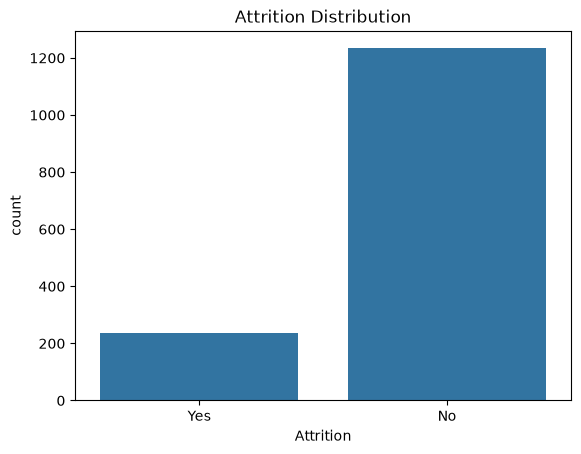

In [2]:
# Check class distribution
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True) * 100)

# Visualize
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

In [3]:
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])

In [4]:
print(df.shape)

(1470, 31)


In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


/var/folders/3q/g2t9cxp52893gsg5lcbt869r0000gn/T/ipykernel_5938/3982002645.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [6]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [7]:
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'], drop_first=True)

In [8]:
print(df.columns.tolist())

['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Marri

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(1176, 44) (294, 44)
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Prevent data leakage

In [11]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC-AUC:  ", roc_auc_score(y_test, y_pred_proba))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy:  0.8605442176870748
Precision: 0.6153846153846154
Recall:    0.3404255319148936
F1 Score:  0.4383561643835616
ROC-AUC:   0.8079076578516668

Confusion Matrix:
[[237  10]
 [ 31  16]]

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [13]:
threshold = 0.3
y_pred_thresh = (y_pred_proba >= threshold).astype(int)
# Lower the threshold for higher recall , that is to capture more people at flight risk according to HR
print(f"Threshold = {threshold}")
print("Precision:", precision_score(y_test, y_pred_thresh))
print("Recall:   ", recall_score(y_test, y_pred_thresh))
print("F1 Score: ", f1_score(y_test, y_pred_thresh))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_thresh))

Threshold = 0.3
Precision: 0.5106382978723404
Recall:    0.5106382978723404
F1 Score:  0.5106382978723404

Confusion Matrix:
[[224  23]
 [ 23  24]]


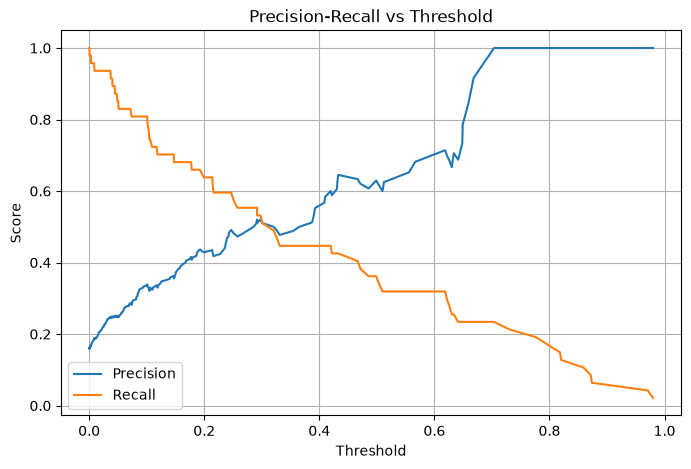

In [14]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)  # note: unscaled data, trees don't need scaling

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:   ", recall_score(y_test, y_pred_rf))
print("F1 Score: ", f1_score(y_test, y_pred_rf))
print("ROC-AUC:  ", roc_auc_score(y_test, y_pred_proba_rf))
print()
print(confusion_matrix(y_test, y_pred_rf))

Accuracy:  0.8333333333333334
Precision: 0.4642857142857143
Recall:    0.2765957446808511
F1 Score:  0.3466666666666667
ROC-AUC:   0.7901197346886036

[[232  15]
 [ 34  13]]


In [16]:
threshold_rf = 0.3
y_pred_rf_thresh = (y_pred_proba_rf >= threshold_rf).astype(int)

print("Precision:", precision_score(y_test, y_pred_rf_thresh))
print("Recall:   ", recall_score(y_test, y_pred_rf_thresh))
print("F1 Score: ", f1_score(y_test, y_pred_rf_thresh))
print(confusion_matrix(y_test, y_pred_rf_thresh))

# precision dropped to 0.35 — meaning more than half of its "Yes" predictions are false alarms - 62 FP

Precision: 0.3541666666666667
Recall:    0.723404255319149
F1 Score:  0.4755244755244755
[[185  62]
 [ 13  34]]


In [17]:
from xgboost import XGBClassifier

# handle imbalance via scale_pos_weight instead of class_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("Accuracy: ", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:   ", recall_score(y_test, y_pred_xgb))
print("F1 Score: ", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:  ", roc_auc_score(y_test, y_pred_proba_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy:  0.8401360544217688
Precision: 0.5
Recall:    0.2978723404255319
F1 Score:  0.37333333333333335
ROC-AUC:   0.737531225773107
[[233  14]
 [ 33  14]]


In [18]:
threshold_xgb = 0.3
y_pred_xgb_thresh = (y_pred_proba_xgb >= threshold_xgb).astype(int)

print("Precision:", precision_score(y_test, y_pred_xgb_thresh))
print("Recall:   ", recall_score(y_test, y_pred_xgb_thresh))
print("F1 Score: ", f1_score(y_test, y_pred_xgb_thresh))
print(confusion_matrix(y_test, y_pred_xgb_thresh))

Precision: 0.43902439024390244
Recall:    0.3829787234042553
F1 Score:  0.4090909090909091
[[224  23]
 [ 29  18]]


In [19]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Top 10 features increasing attrition risk:")
print(coefficients.head(10))

print("\nTop 10 features decreasing attrition risk:")
print(coefficients.tail(10))

Top 10 features increasing attrition risk:
                             Feature  Coefficient
13                          OverTime     0.864567
25  BusinessTravel_Travel_Frequently     0.751247
35     JobRole_Laboratory Technician     0.714756
23           YearsSinceLastPromotion     0.528704
12                NumCompaniesWorked     0.487609
41      JobRole_Sales Representative     0.481459
26      BusinessTravel_Travel_Rarely     0.450070
40           JobRole_Sales Executive     0.409361
2                   DistanceFromHome     0.393594
43              MaritalStatus_Single     0.376877

Top 10 features decreasing attrition risk:
                         Feature  Coefficient
22            YearsInCurrentRole    -0.356016
29  EducationField_Life Sciences    -0.356181
38     JobRole_Research Director    -0.361341
7                 JobInvolvement    -0.365340
24          YearsWithCurrManager    -0.398368
0                            Age    -0.407597
31        EducationField_Medical    -0.41

In [22]:
# FINAL: Predict Attrition for a New Employee

# Step 1: Enter the new employee's raw data
new_employee = pd.DataFrame([{
    'Age': 29,
    'BusinessTravel': 'Travel_Frequently',
    'DailyRate': 800,
    'Department': 'Sales',
    'DistanceFromHome': 10,
    'Education': 3,
    'EducationField': 'Marketing',
    'EnvironmentSatisfaction': 2,
    'Gender': 'Male',
    'HourlyRate': 60,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobRole': 'Sales Executive',
    'JobSatisfaction': 2,
    'MaritalStatus': 'Single',
    'MonthlyIncome': 4500,
    'MonthlyRate': 15000,
    'NumCompaniesWorked': 3,
    'OverTime': 'Yes',
    'PercentSalaryHike': 12,
    'PerformanceRating': 3,
    'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0,
    'TotalWorkingYears': 6,
    'TrainingTimesLastYear': 2,
    'WorkLifeBalance': 2,
    'YearsAtCompany': 2,
    'YearsInCurrentRole': 1,
    'YearsSinceLastPromotion': 0,
    'YearsWithCurrManager': 1
}])

# Step 2: Apply the SAME preprocessing as training data
new_employee['OverTime'] = new_employee['OverTime'].map({'Yes': 1, 'No': 0})
new_employee['Gender'] = new_employee['Gender'].map({'Male': 1, 'Female': 0})

new_employee = pd.get_dummies(
    new_employee,
    columns=['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'],
    drop_first=True
)

# Step 3: Align columns exactly to training data (fills missing dummy cols with 0)
new_employee = new_employee.reindex(columns=X.columns, fill_value=0)

# Step 4: Scale (Logistic Regression needs this; skip for RF/XGBoost)
new_employee_scaled = scaler.transform(new_employee)

# Step 5: Get probability from the model
probability = log_reg.predict_proba(new_employee_scaled)[:, 1][0]

# Step 6: Apply YOUR chosen threshold (0.3), not the model's default 0.5
threshold = 0.3
final_prediction = "Yes" if probability >= threshold else "No"

# Step 7: Output
print(f"Probability of Leaving: {round(probability, 3)}")
print(f"Predicted Attrition (threshold={threshold}): {final_prediction}")

Probability of Leaving: 0.389
Predicted Attrition (threshold=0.3): Yes


- If goal is balanced overall performance go with Logistic Regression @ 0.3 threshold — best F1, best AUC, and it's simpler and more interpretable to explain in a report.
- If framing this as "help HR catch people at risk of leaving" and treating false negatives (missed leavers) as more costly than false alarms: Random Forest @ 0.3 is defensible despite lower F1, because 72% recall vs 51% is a meaningfully bigger safety net, and you can state that tradeoff explicitly as your reasoning.

In [26]:
# FINAL: Predict Attrition (Random Forest, threshold=0.3)

# Step 1: Enter the new employee's raw data
new_employee_rf = pd.DataFrame([{
    'Age': 35,
    'BusinessTravel': 'Travel_Frequently',
    'DailyRate': 5000,
    'Department': 'Sales',
    'DistanceFromHome': 10,
    'Education': 3,
    'EducationField': 'Marketing',
    'EnvironmentSatisfaction': 2,
    'Gender': 'Male',
    'HourlyRate': 60,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobRole': 'Sales Executive',
    'JobSatisfaction': 2,
    'MaritalStatus': 'Single',
    'MonthlyIncome': 4500,
    'MonthlyRate': 15000,
    'NumCompaniesWorked': 3,
    'OverTime': 'Yes',
    'PercentSalaryHike': 12,
    'PerformanceRating': 3,
    'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0,
    'TotalWorkingYears': 6,
    'TrainingTimesLastYear': 2,
    'WorkLifeBalance': 6,
    'YearsAtCompany': 2,
    'YearsInCurrentRole': 1,
    'YearsSinceLastPromotion': 0,
    'YearsWithCurrManager': 1
}])

# Step 2: Apply the SAME preprocessing as training data
new_employee_rf['OverTime'] = new_employee_rf['OverTime'].map({'Yes': 1, 'No': 0})
new_employee_rf['Gender'] = new_employee_rf['Gender'].map({'Male': 1, 'Female': 0})

new_employee_rf = pd.get_dummies(
    new_employee_rf,
    columns=['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'],
    drop_first=True
)

# Step 3: Align columns exactly to training data
new_employee_rf = new_employee_rf.reindex(columns=X.columns, fill_value=0)

# Step 4: NO SCALING — Random Forest doesn't need it, use raw values directly

# Step 5: Get probability from the Random Forest model
probability_rf = rf.predict_proba(new_employee_rf)[:, 1][0]

# Step 6: Apply the 0.3 threshold you chose for Random Forest
threshold_rf = 0.3
final_prediction_rf = "Yes" if probability_rf >= threshold_rf else "No"

# Step 7: Output
print(f"Probability of Leaving (RF): {round(probability_rf, 3)}")
print(f"Predicted Attrition (RF, threshold={threshold_rf}): {final_prediction_rf}")

Probability of Leaving (RF): 0.45
Predicted Attrition (RF, threshold=0.3): Yes
